#Breast cancer using Big Data Tools

In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("Breast Cancer Analysis") \
    .getOrCreate()

In [2]:
if (spark.getActiveSession()):
    print('yes')
else:
    print('no')

yes


In [3]:
spark_df = spark.read.csv("breast_cancer.csv", header=True, inferSchema=True)

In [4]:
spark_df.printSchema()
spark_df.show(5)

root
 |-- id: integer (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- radius_mean: double (nullable = true)
 |-- texture_mean: double (nullable = true)
 |-- perimeter_mean: double (nullable = true)
 |-- area_mean: double (nullable = true)
 |-- smoothness_mean: double (nullable = true)
 |-- compactness_mean: double (nullable = true)
 |-- concavity_mean: double (nullable = true)
 |-- concave points_mean: double (nullable = true)
 |-- symmetry_mean: double (nullable = true)
 |-- fractal_dimension_mean: double (nullable = true)
 |-- radius_se: double (nullable = true)
 |-- texture_se: double (nullable = true)
 |-- perimeter_se: double (nullable = true)
 |-- area_se: double (nullable = true)
 |-- smoothness_se: double (nullable = true)
 |-- compactness_se: double (nullable = true)
 |-- concavity_se: double (nullable = true)
 |-- concave points_se: double (nullable = true)
 |-- symmetry_se: double (nullable = true)
 |-- fractal_dimension_se: double (nullable = true)
 |-- radi

In [5]:
print("Number of rows:", spark_df.count())
print("Number of columns:", len(spark_df.columns))
print("Column names:", spark_df.columns)

Number of rows: 569
Number of columns: 33
Column names: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', '_c32']


In [6]:
df_pandas = spark_df.toPandas()
row_50 = df_pandas.iloc[49]
radius_mean_value = row_50['radius_mean']

print("50th Row:")
print(row_50)
print("\nRadius Mean Value:", radius_mean_value)

50th Row:
id                           857156
diagnosis                         B
radius_mean                   13.49
texture_mean                   22.3
perimeter_mean                86.91
area_mean                     561.0
smoothness_mean             0.08752
compactness_mean            0.07698
concavity_mean              0.04751
concave points_mean         0.03384
symmetry_mean                0.1809
fractal_dimension_mean      0.05718
radius_se                    0.2338
texture_se                    1.353
perimeter_se                  1.735
area_se                        20.2
smoothness_se              0.004455
compactness_se              0.01382
concavity_se                0.02095
concave points_se           0.01184
symmetry_se                 0.01641
fractal_dimension_se       0.001956
radius_worst                  15.15
texture_worst                 31.82
perimeter_worst                99.0
area_worst                    698.8
smoothness_worst             0.1162
compactness_worst 

In [7]:
m_count = df_pandas[df_pandas['diagnosis'] == 'M'].shape[0]

b_count = df_pandas[df_pandas['diagnosis'] == 'B'].shape[0]

diagnosis_diff = m_count - b_count
print("Malignant count:", m_count)
print("Benign count:", b_count)
print("Difference:", diagnosis_diff)

Malignant count: 212
Benign count: 357
Difference: -145


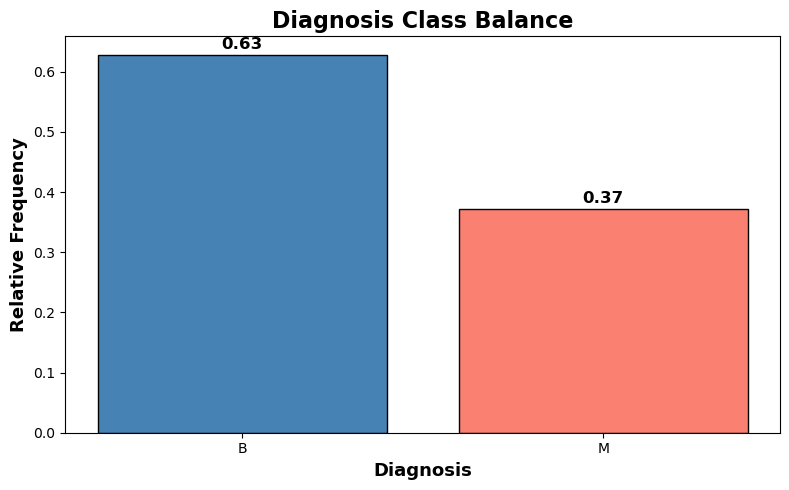

0.37258347978910367

In [8]:
relative_frequencies = df_pandas['diagnosis'].value_counts(normalize=True)
plt.figure(figsize=(8, 5))
plt.bar(
    relative_frequencies.index,
    relative_frequencies.values,
    color=['steelblue', 'salmon'],
    edgecolor='black'
)

# Add labels and title
plt.title('Diagnosis Class Balance', fontsize=16, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=13, fontweight='bold')
plt.ylabel('Relative Frequency', fontsize=13, fontweight='bold')

# Add value labels on top of each bar
for i, value in enumerate(relative_frequencies.values):
    plt.text(i, value + 0.01, f'{value:.2f}', 
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print relative frequency of Malignant cases
relative_frequencies['M']



In [9]:
spark_df.describe().show()

+-------+--------------------+---------+------------------+-----------------+-----------------+-----------------+--------------------+-------------------+-------------------+--------------------+--------------------+----------------------+------------------+------------------+------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+------------------+------------------+-----------------+--------------------+-------------------+-------------------+--------------------+-------------------+-----------------------+----+
|summary|                  id|diagnosis|       radius_mean|     texture_mean|   perimeter_mean|        area_mean|     smoothness_mean|   compactness_mean|     concavity_mean| concave points_mean|       symmetry_mean|fractal_dimension_mean|         radius_se|        texture_se|      perimeter_se|          area_se|       smoothness_se|      compactness_

In [10]:
# Convert to Pandas
df_pandas = spark_df.toPandas()

# Maximum of fractal_dimension_mean
max_fractal_dimension_mean = df_pandas['fractal_dimension_mean'].max()

# Minimum of symmetry_mean
min_symmetry_mean = df_pandas['symmetry_mean'].min()

# Absolute difference rounded to 4 decimal places
range_diff = round(abs(max_fractal_dimension_mean - min_symmetry_mean), 4)

print("Max Fractal Dimension Mean:", max_fractal_dimension_mean)
print("Min Symmetry Mean:", min_symmetry_mean)
print("Range Difference:", range_diff)
range_diff

Max Fractal Dimension Mean: 0.09744
Min Symmetry Mean: 0.106
Range Difference: 0.0086


0.0086

In [11]:
# Filter only Benign cases
benign_df = df_pandas[df_pandas['diagnosis'] == 'B']

# Calculate averages rounded to 2 decimal places
radius_mean_b = round(benign_df['radius_mean'].mean(), 2)
texture_mean_b = round(benign_df['texture_mean'].mean(), 2)
perimeter_mean_b = round(benign_df['perimeter_mean'].mean(), 2)

# Print each value
print("Average Radius Mean (Benign):", radius_mean_b)
print("Average Texture Mean (Benign):", texture_mean_b)
print("Average Perimeter Mean (Benign):", perimeter_mean_b)

# Return the product of the three rounded means
radius_mean_b * texture_mean_b * perimeter_mean_b

Average Radius Mean (Benign): 12.15
Average Texture Mean (Benign): 17.91
Average Perimeter Mean (Benign): 78.08


16990.71552

In [12]:
# Filter only Malignant cases
malignant_df = df_pandas[df_pandas['diagnosis'] == 'M']

# Calculate ratio of radius_mean and perimeter_mean for each row
ratios = malignant_df['radius_mean'] / malignant_df['perimeter_mean']

# Calculate average of ratios rounded to 2 decimal places
mean_radius_perimeter_ratio = round(ratios.mean(), 2)

# Print results
print("Ratios (first 5):", ratios.head())
print("Mean Radius Perimeter Ratio:", mean_radius_perimeter_ratio)

mean_radius_perimeter_ratio

Ratios (first 5): 0    0.146498
1    0.154778
2    0.151462
3    0.147203
4    0.150185
dtype: float64
Mean Radius Perimeter Ratio: 0.15


0.15

In [13]:
spark.stop()

if (spark.getActiveSession()):
    print('yes')
else:
    print('yes')

yes
